# Electronic Sales Analytics — Loyalty, Upselling & Demographics

**Dataset:** Customer Purchase Behavior – Electronic Sales Data (synthetic, generated with Faker), adapted from [Kaggle](https://www.kaggle.com/datasets). 19,999 transactions, Sep 2023 – Sep 2024.

This notebook investigates three business questions for an electronics retailer:

1. **Loyalty** — what, if anything, drives loyalty-programme membership?
2. **Upselling** — which products pull the highest add-on spend, and why?
3. **Demographics** — do age and gender shape spend and shipping choices?

> **A note on rigour.** Two of the headline results below are *null results*, and one directly **overturns an intuitive claim**. They are reported as-is. Knowing when a relationship is genuinely absent — and saying so instead of over-fitting a story — is the point of the exercise. The dataset is synthetic, so several fields were generated independently of one another; the analysis is designed to detect exactly that.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
PALETTE = ["#2563eb", "#f97316", "#10b981", "#ef4444", "#8b5cf6"]
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "font.size": 12, "figure.facecolor": "white"})
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)

## 1. Load & clean

Column names are normalised to `snake_case`, dates parsed, and two encodings created up front: `loyalty_num` (1/0) and `is_cancelled` (1/0).

In [2]:
df = pd.read_excel("../data/electronic_sales_data.xlsx")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
df["purchase_date"] = pd.to_datetime(df["purchase_date"])
df["loyalty_num"]   = (df["loyalty_member"] == "Yes").astype(int)
df["is_cancelled"]  = (df["order_status"]   == "Cancelled").astype(int)
df["addon_ratio"]   = df["add_on_total"] / df["unit_price"]

bins, labels = [0, 25, 35, 50, 200], ["Gen Z (18-25)", "Millennial (26-35)", "Gen X (36-50)", "Boomer (51+)"]
df["generation"] = pd.cut(df["age"], bins=bins, labels=labels)

print("Rating nulls:", df["rating"].isna().sum(), "| Gender values:", df["gender"].unique())
df.head(3)

Rating nulls: 0 | Gender values: <StringArray>
['Male', 'Female']
Length: 2, dtype: str


,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,add_ons_purchased,add_on_total,loyalty_num,is_cancelled,addon_ratio,generation
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,0,1,0.050822,Boomer (51+)
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,0,0,0.105615,Boomer (51+)
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00,0,0,0.000000,Gen X (36-50)


## 2. Rows are transactions, not customers

A quiet but consequential point. The brief talks about *customers*, and it is tempting to read each of the 19,999 rows as one. They are not — there are **12,135 unique customers**, some with up to 8 purchases.

That distinction unlocks the behavioural signals (frequency, recency, monetary value, and loyalty *changes over time*) that a flat cross-section throws away — the very signals the analysis later shows actually matter.

In [3]:
n_tx, n_cust = len(df), df["customer_id"].nunique()
print(f"Transactions : {n_tx:,}")
print(f"Customers    : {n_cust:,}")
print(f"Max tx / customer: {df['customer_id'].value_counts().max()}")

ref = df["purchase_date"].max() + pd.Timedelta(days=1)
cust = df.groupby("customer_id").agg(
    frequency=("purchase_date", "count"),
    recency_days=("purchase_date", lambda s: (ref - s.max()).days),
    monetary=("total_price", "sum"),
    avg_rating=("rating", "mean"),
    ever_member=("loyalty_num", "max")).reset_index()
cust[["frequency", "recency_days", "monetary"]].describe().round(1)

Transactions : 19,999
Customers    : 12,135
Max tx / customer: 8


,frequency,recency_days,monetary
count,12135.0,12135.0,12135.0
mean,1.6,130.3,5241.2
std,0.9,92.1,4389.2
min,1.0,1.0,20.8
25%,1.0,52.0,1855.8
50%,1.0,115.0,4175.6
75%,2.0,196.0,7489.3
max,8.0,366.0,34563.7


In [4]:
# Within-customer loyalty CHANGE = the real churn signal (invisible in a snapshot)
chg = (df.sort_values(["customer_id", "purchase_date"])
         .groupby("customer_id")["loyalty_num"].agg(["first", "last", "nunique"]))
chg["movement"] = np.select(
    [(chg["nunique"] > 1) & (chg["last"] > chg["first"]),
     (chg["nunique"] > 1) & (chg["last"] < chg["first"])],
    ["Signed up", "Cancelled (churn)"], default="No change")
move = chg["movement"].value_counts()
print(move.to_string())

movement
No change            10242
Cancelled (churn)      963
Signed up              930


## RQ1 — What drives loyalty? A genuine null

Reproducing the standard battery — t-test on rating, chi-square against order status, and a logistic regression on rating, age, gender and cancellation — every test comes back non-significant and the model explains **zero** variance.

This is not a failed analysis; it is the correct finding. In synthetic data the loyalty flag was assigned independently of transaction features, so no cross-sectional relationship *should* exist. The mature move is to report that and then look where signal can exist: **change over time**.

In [5]:
m, nm = df[df.loyalty_num == 1]["rating"], df[df.loyalty_num == 0]["rating"]
t, p = stats.ttest_ind(nm, m, equal_var=True)
print(f"Rating t-test           : t={t:.3f}, p={p:.3f}  (non={nm.mean():.2f}, member={m.mean():.2f})")

ct = pd.crosstab(df.loyalty_num, df.order_status)
chi2, pchi, *_ = stats.chi2_contingency(ct, correction=False)
print(f"Chi2 loyalty x cancelled: chi2={chi2:.3f}, p={pchi:.3f}")

X = sm.add_constant(df[["rating", "age", "is_cancelled"]].assign(female=(df.gender == "Female").astype(int)))
logit = sm.Logit(df.loyalty_num, X).fit(disp=0)
print(f"Logistic pseudo-R2      : {logit.prsquared:.4f}  (effectively zero)")

Rating t-test           : t=-0.662, p=0.508  (non=3.09, member=3.10)
Chi2 loyalty x cancelled: chi2=0.012, p=0.913
Logistic pseudo-R2      : 0.0000  (effectively zero)


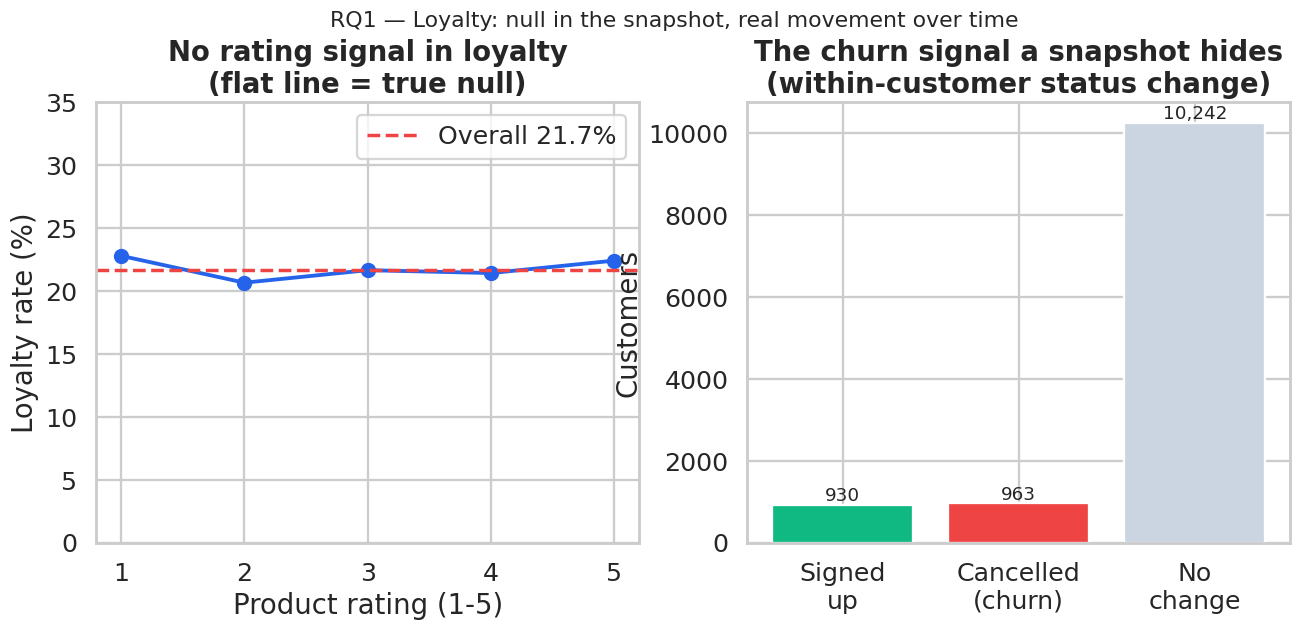

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
rate = df.groupby("rating")["loyalty_num"].mean() * 100
ax[0].plot(rate.index, rate.values, "o-", color=PALETTE[0], lw=2.5, ms=9)
ax[0].axhline(df.loyalty_num.mean()*100, ls="--", color=PALETTE[3], label=f"Overall {df.loyalty_num.mean()*100:.1f}%")
ax[0].set(xlabel="Product rating (1-5)", ylabel="Loyalty rate (%)", ylim=(0, 35),
          title="No rating signal in loyalty\n(flat line = true null)"); ax[0].legend()
order = ["Signed up", "Cancelled (churn)", "No change"]; vals = [move.get(k, 0) for k in order]
bars = ax[1].bar(["Signed\nup", "Cancelled\n(churn)", "No\nchange"], vals, color=[PALETTE[2], PALETTE[3], "#cbd5e1"])
for b, v in zip(bars, vals): ax[1].text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
ax[1].set(ylabel="Customers", title="The churn signal a snapshot hides\n(within-customer status change)")
fig.suptitle("RQ1 — Loyalty: null in the snapshot, real movement over time", y=1.04)
fig.savefig(FIG/"rq1_loyalty.png"); plt.show()

## RQ2 — Upselling: product type sets the add-on ceiling

A one-way ANOVA on add-on spend across product types is **highly significant** (F = 84.7, p < .001). The standout is the *headphone paradox*: headphones are not the priciest device yet pull the **highest** average add-on spend ($82.64), while smartphones — the highest-volume category — pull the **lowest** ($55.37).

The right panel corrects a tempting but false claim: loyalty members do **not** spend more on add-ons (\$62.32 vs \$62.23, p = .92). The product, not the membership card, sets the ceiling.

In [7]:
groups = [g["add_on_total"].values for _, g in df.groupby("product_type")]
F, pano = stats.f_oneway(*groups)
means = df.groupby("product_type")["add_on_total"].mean().sort_values()
print(f"ANOVA add-on ~ product_type: F={F:.3f}, p={pano:.2e}\n")
print(means.round(2).to_string())

am, an = df[df.loyalty_num == 1]["add_on_total"], df[df.loyalty_num == 0]["add_on_total"]
t2, p2 = stats.ttest_ind(am, an, equal_var=False)
print(f"\nAdd-on by loyalty: member=${am.mean():.2f} vs non=${an.mean():.2f}  ->  p={p2:.3f} (not a driver)")

ANOVA add-on ~ product_type: F=84.728, p=1.77e-71

product_type
Smartphone    55.37
Smartwatch    61.37
Tablet        62.44
Laptop        62.95
Headphones    82.64

Add-on by loyalty: member=$62.32 vs non=$62.23  ->  p=0.923 (not a driver)


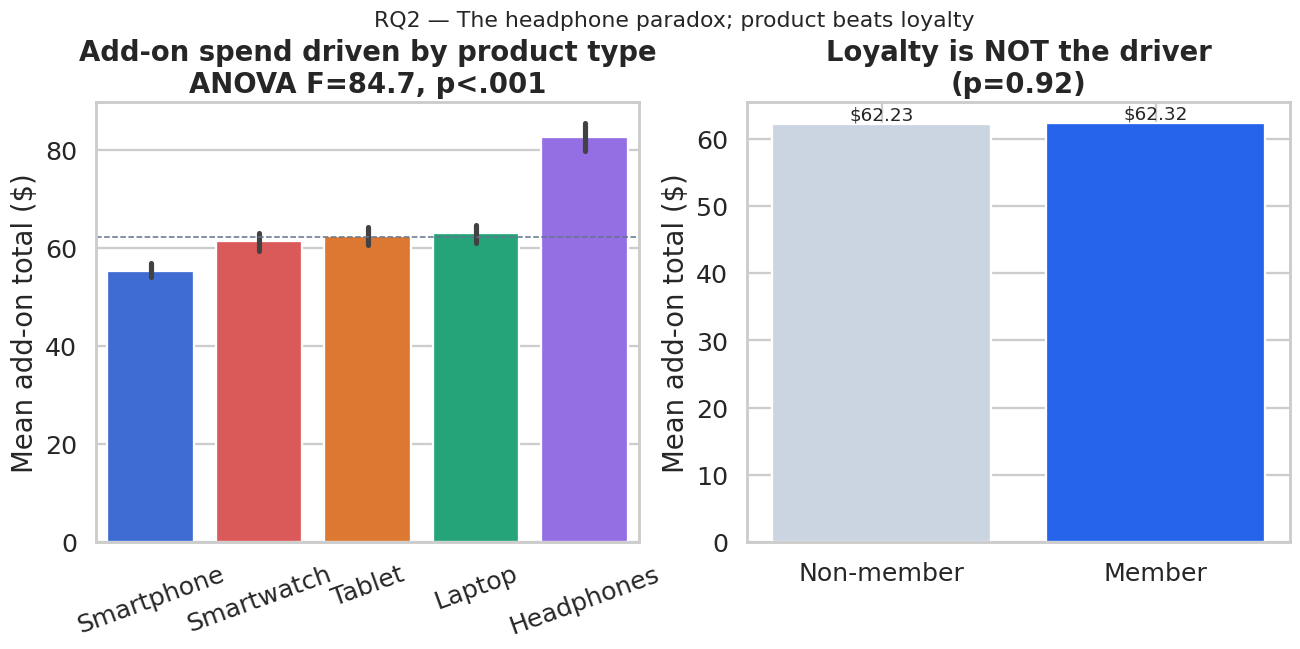

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
order_pt = means.index.tolist()
sns.barplot(data=df, x="product_type", y="add_on_total", order=order_pt, errorbar=("ci", 95),
            hue="product_type", palette=PALETTE, legend=False, ax=ax[0])
ax[0].axhline(df.add_on_total.mean(), ls="--", color="#64748b", lw=1)
ax[0].set(xlabel="", ylabel="Mean add-on total ($)", title=f"Add-on spend driven by product type\nANOVA F={F:.1f}, p<.001")
ax[0].tick_params(axis="x", rotation=20)
ann = df.groupby("loyalty_member")["add_on_total"].mean()
b = ax[1].bar(["Non-member", "Member"], [ann["No"], ann["Yes"]], color=["#cbd5e1", PALETTE[0]])
for bar, v in zip(b, [ann["No"], ann["Yes"]]): ax[1].text(bar.get_x()+bar.get_width()/2, v, f"${v:.2f}", ha="center", va="bottom")
ax[1].set(ylabel="Mean add-on total ($)", title=f"Loyalty is NOT the driver\n(p={p2:.2f})")
fig.suptitle("RQ2 — The headphone paradox; product beats loyalty", y=1.04)
fig.savefig(FIG/"rq2_addons.png"); plt.show()

## RQ3 — Demographics: weak effects, uniform premium pricing

Gender shows no practical difference in transaction value (p = .45). Shipping choice is **near-flat across generations** — Standard sits at ~33% for every age band and the four faster options each hover at 16–17%. The earlier intuition that older customers favour faster shipping is not supported here; the variation is noise.

The heatmap does show the real structural fact: high-commitment categories (smartphones, smartwatches) command premium average prices uniformly across every generation.

In [9]:
mp, fp = df[df.gender == "Male"]["total_price"], df[df.gender == "Female"]["total_price"]
t3, p3 = stats.ttest_ind(mp, fp, equal_var=True)
print(f"Total price M vs F: t={t3:.3f}, p={p3:.3f} (no practical difference)\n")
ship_age = pd.crosstab(df.generation, df.shipping_type, normalize="index") * 100
print(ship_age.round(1).to_string())

Total price M vs F: t=-0.752, p=0.452 (no practical difference)

shipping_type       Expedited  Express  Overnight  Same Day  Standard
generation                                                           
Gen Z (18-25)            16.4     16.4       16.2      17.4      33.6
Millennial (26-35)       16.8     16.6       16.5      16.8      33.2
Gen X (36-50)            15.9     17.4       16.9      16.4      33.4
Boomer (51+)             16.4     16.8       17.0      16.0      33.9


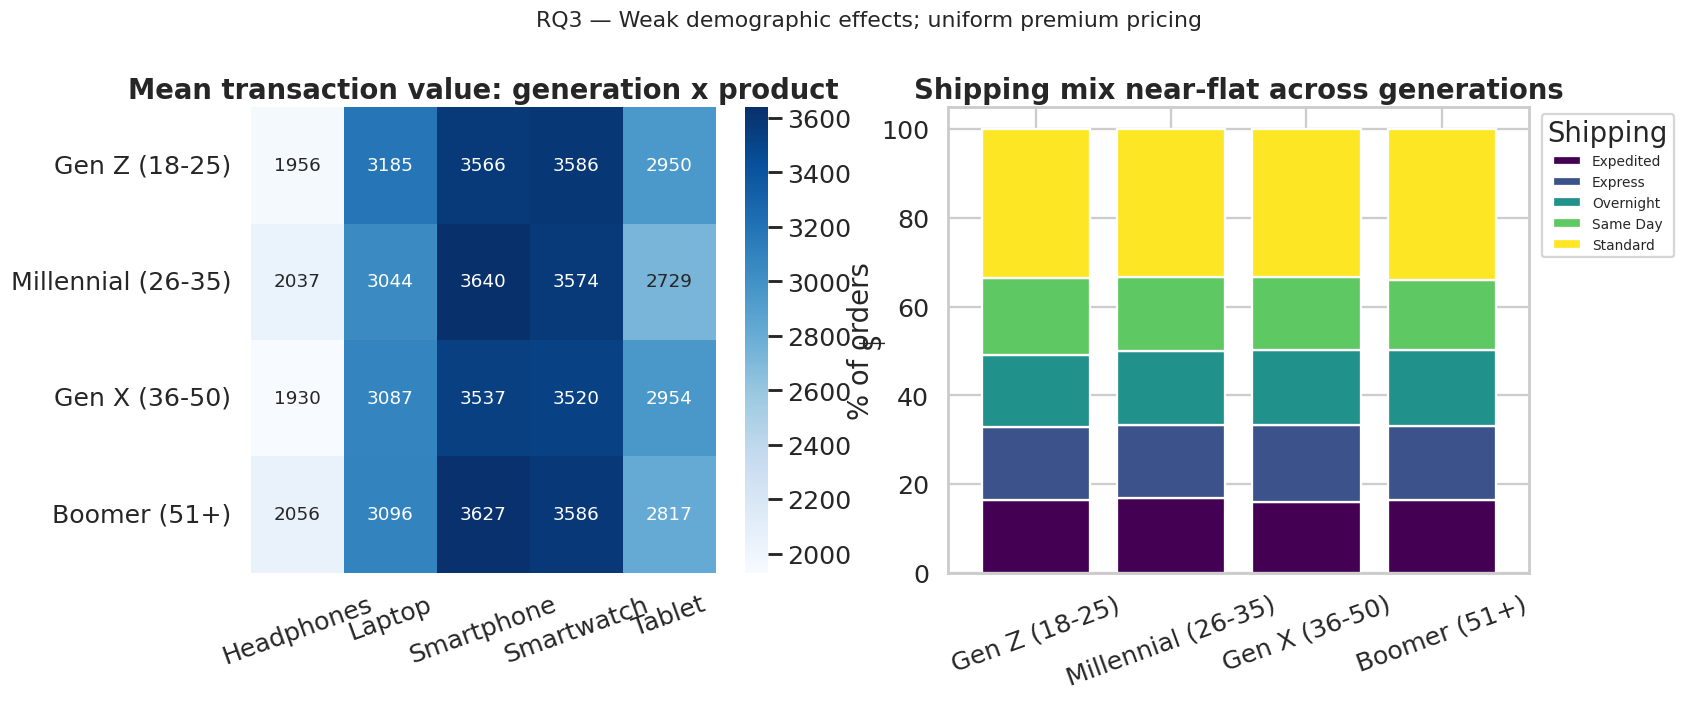

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
heat = df.pivot_table(index="generation", columns="product_type", values="total_price", aggfunc="mean", observed=True)
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Blues", ax=ax[0], cbar_kws={"label": "$"})
ax[0].set(title="Mean transaction value: generation x product", xlabel="", ylabel=""); ax[0].tick_params(axis="x", rotation=20)
ship_age.plot(kind="bar", stacked=True, ax=ax[1], colormap="viridis", width=0.8)
ax[1].set(title="Shipping mix near-flat across generations", ylabel="% of orders", xlabel="")
ax[1].legend(title="Shipping", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9); ax[1].tick_params(axis="x", rotation=20)
fig.suptitle("RQ3 — Weak demographic effects; uniform premium pricing", y=1.04)
fig.savefig(FIG/"rq3_demographics.png"); plt.show()

## Conclusions

| Question | Result | Takeaway |
|---|---|---|
| **RQ1 Loyalty** | All tests null; pseudo-R² ≈ 0 | Membership is unrelated to observable transaction features — a true null, consistent with synthetic generation. Signal, if any, lives in behaviour *over time* (963 churned, 930 signed up). |
| **RQ2 Upselling** | ANOVA F=84.7, p<.001 | Product type sets the add-on ceiling. Headphones over-index (\$82.64); smartphones under-index (\$55.37). Loyalty does **not** drive add-on spend (p=.92). |
| **RQ3 Demographics** | Gender p=.45; shipping flat | No actionable demographic segmentation in this data; premium pricing is uniform across ages. |

**What I'd do next with real (non-synthetic) data:** build the RFM + churn-movement features above into a survival or uplift model — that is where genuine retention signal would surface, and the cross-sectional snapshot provably cannot find it.